In [1]:
pip install pandas matplotlib seaborn google-cloud-bigquery db-dtypes

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

print("Libraries loaded ✓")

Libraries loaded ✓


In [4]:
# If you uploaded via the Colab file panel (left sidebar → Files → Upload)
# use this:
rfm      = pd.read_csv('rfm_segments.csv')
funnel   = pd.read_csv('funnel_table.csv')
campaign = pd.read_csv('campaign_table.csv')
customer = pd.read_csv('customer_level.csv')

print("Rows loaded:")
print(f"  rfm_segments:   {len(rfm):,}")
print(f"  funnel_table:   {len(funnel):,}")
print(f"  campaign_table: {len(campaign):,}")
print(f"  customer_level: {len(customer):,}")

Rows loaded:
  rfm_segments:   5,577
  funnel_table:   5
  campaign_table: 16
  customer_level: 5,577


In [6]:
SEG_ORDER = [
    'Champions',
    'Big Spenders',
    'Loyal High-Value',
    'New Customers',
    'Low / Medium Value',
    'At Risk',
]

SEG_COLORS = {
    'Champions':          '#1D9E75',
    'Big Spenders':       '#3266AD',
    'Loyal High-Value':   '#7F77DD',
    'New Customers':      '#EF9F27',
    'Low / Medium Value': '#888780',
    'At Risk':            '#E24B4A',
}

# Pre-aggregate RFM data — used across multiple figures
seg_agg = (
    rfm.groupby('rfm_segment')
    .agg(
        customers        = ('user_id', 'count'),
        avg_spend        = ('total_spend', 'mean'),
        avg_frequency    = ('frequency', 'mean'),
        avg_recency      = ('recency_days', 'mean'),
        avg_camp_clicks  = ('campaign_clicks', 'mean'),
        avg_triggered    = ('triggered_clicks', 'mean'),
        avg_view         = ('view_clicks', 'mean'),
        avg_cart         = ('cart_clicks', 'mean'),
    )
    .reset_index()
)
seg_agg['pct_base']      = seg_agg['customers'] / seg_agg['customers'].sum() * 100
seg_agg['triggered_pct'] = seg_agg['avg_triggered'] / seg_agg['avg_camp_clicks'] * 100
seg_agg['cart_rate']     = seg_agg['avg_cart'] / seg_agg['avg_view'] * 100
seg_agg['color']         = seg_agg['rfm_segment'].map(SEG_COLORS)
seg_agg = seg_agg.set_index('rfm_segment').loc[SEG_ORDER].reset_index()

print("Aggregation ready ✓")
print(seg_agg[['rfm_segment','customers','avg_spend','pct_base']].to_string(index=False))

Aggregation ready ✓
       rfm_segment  customers   avg_spend  pct_base
         Champions        764 1938.869385 13.699121
      Big Spenders        926 1582.631080 16.603909
  Loyal High-Value        997 1243.404604 17.876995
     New Customers        766  232.119413 13.734983
Low / Medium Value       1969  230.036765 35.305720
           At Risk        155  169.976129  2.779272


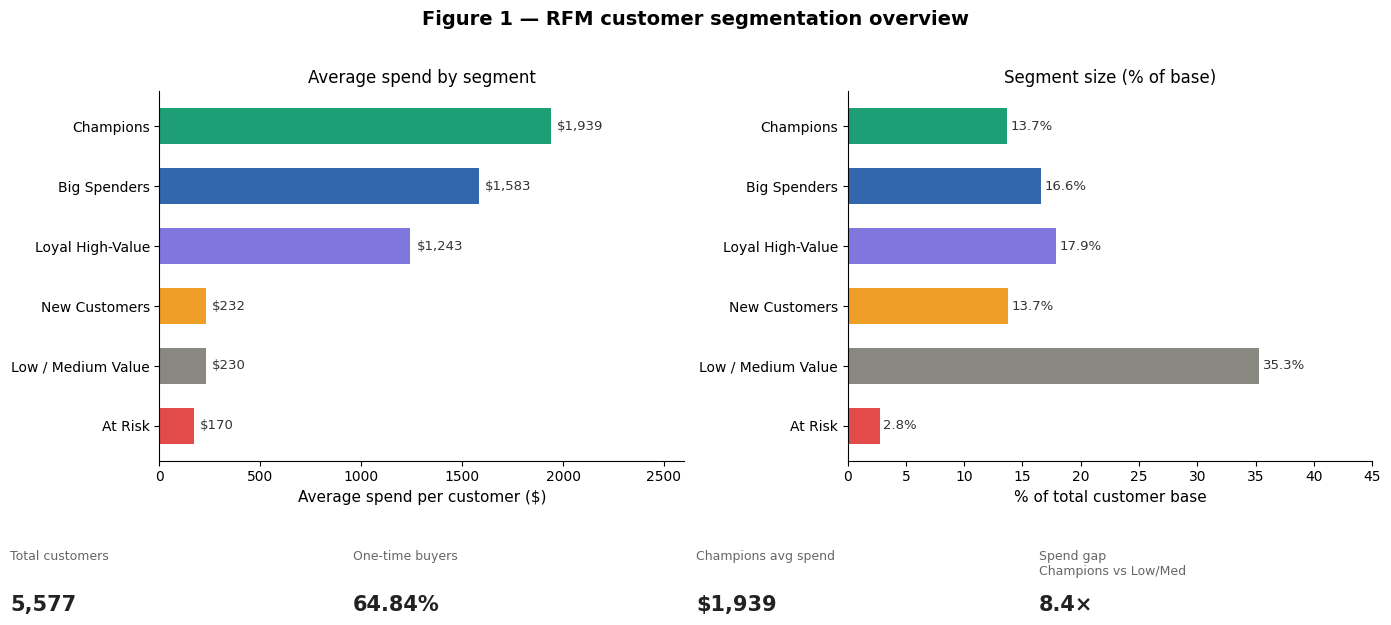

Figure 1 saved


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Figure 1 — RFM customer segmentation overview',
    fontsize=14, fontweight='bold', y=1.02
)

# ── Left: average spend ──────────────────────────────────────────────────────
bars = axes[0].barh(
    seg_agg['rfm_segment'],
    seg_agg['avg_spend'],
    color=seg_agg['color'],
    height=0.6
)
axes[0].invert_yaxis()
axes[0].set_xlabel('Average spend per customer ($)', fontsize=11)
axes[0].set_title('Average spend by segment', fontsize=12)
axes[0].set_xlim(0, 2600)
axes[0].tick_params(axis='y', labelsize=10)

for bar, val in zip(bars, seg_agg['avg_spend']):
    axes[0].text(
        bar.get_width() + 30,
        bar.get_y() + bar.get_height() / 2,
        f'${val:,.0f}',
        va='center', fontsize=9.5, color='#333'
    )

# ── Right: % of base ─────────────────────────────────────────────────────────
bars2 = axes[1].barh(
    seg_agg['rfm_segment'],
    seg_agg['pct_base'],
    color=seg_agg['color'],
    height=0.6
)
axes[1].invert_yaxis()
axes[1].set_xlabel('% of total customer base', fontsize=11)
axes[1].set_title('Segment size (% of base)', fontsize=12)
axes[1].set_xlim(0, 45)
axes[1].tick_params(axis='y', labelsize=10)

for bar, val in zip(bars2, seg_agg['pct_base']):
    axes[1].text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%',
        va='center', fontsize=9.5, color='#333'
    )

# ── Key stats below ──────────────────────────────────────────────────────────
stats = [
    ('Total customers', '5,577'),
    ('One-time buyers', '64.84%'),
    ('Champions avg spend', '$1,939'),
    ('Spend gap\nChampions vs Low/Med', '8.4×'),
]
for i, (label, val) in enumerate(stats):
    fig.text(0.01 + i * 0.245, -0.06, label,
             fontsize=9, color='#666', ha='left', va='top')
    fig.text(0.01 + i * 0.245, -0.15, val,
             fontsize=15, fontweight='bold', color='#222', ha='left', va='top')

plt.tight_layout()
plt.savefig('figure1_rfm_segments.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 1 saved")

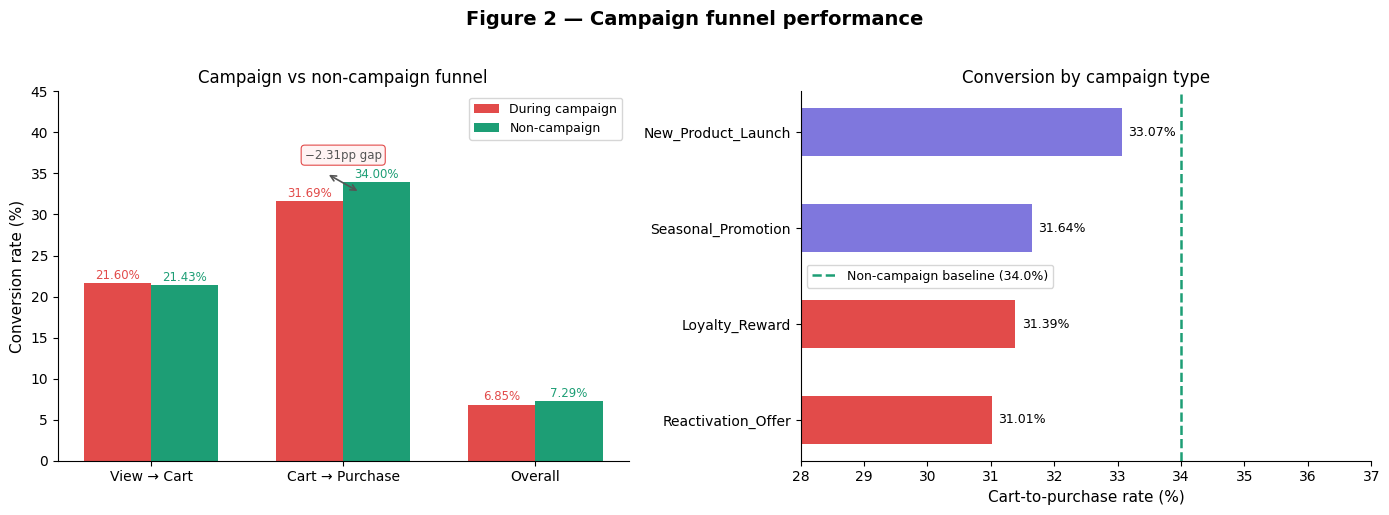

Figure 2 saved


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Figure 2 — Campaign funnel performance',
    fontsize=14, fontweight='bold', y=1.02
)

# ── Aggregate campaign vs non-campaign ───────────────────────────────────────
camp = funnel[funnel['campaign_active'] == 1].agg(
    {'views': 'sum', 'carts': 'sum', 'purchase_clicks': 'sum'}
)
non = funnel[funnel['campaign_active'] == 0].agg(
    {'views': 'sum', 'carts': 'sum', 'purchase_clicks': 'sum'}
)

v2c_c = camp['carts'] / camp['views'] * 100
v2c_n = non['carts']  / non['views']  * 100
c2p_c = camp['purchase_clicks'] / camp['carts'] * 100
c2p_n = non['purchase_clicks']  / non['carts']  * 100
ov_c  = camp['purchase_clicks'] / camp['views'] * 100
ov_n  = non['purchase_clicks']  / non['views']  * 100

labels     = ['View → Cart', 'Cart → Purchase', 'Overall']
camp_vals  = [v2c_c, c2p_c, ov_c]
non_vals   = [v2c_n, c2p_n, ov_n]

x = np.arange(len(labels))
w = 0.35

b1 = axes[0].bar(x - w/2, camp_vals, w, color='#E24B4A', label='During campaign')
b2 = axes[0].bar(x + w/2, non_vals,  w, color='#1D9E75', label='Non-campaign')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=10)
axes[0].set_ylabel('Conversion rate (%)', fontsize=11)
axes[0].set_title('Campaign vs non-campaign funnel', fontsize=12)
axes[0].set_ylim(0, 45)
axes[0].legend(fontsize=9)

for bar, val in zip(b1, camp_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.2f}%', ha='center', fontsize=8.5, color='#E24B4A')
for bar, val in zip(b2, non_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.2f}%', ha='center', fontsize=8.5, color='#1D9E75')

# Annotate the gap on Cart → Purchase bar
axes[0].annotate('', xy=(1 - w/2 + w/4, c2p_n + 1),
                     xytext=(1 + w/2 - w/4, c2p_c + 1),
    arrowprops=dict(arrowstyle='<->', color='#555', lw=1.2))
axes[0].text(1, max(c2p_n, c2p_c) + 2.8, '−2.31pp gap',
             ha='center', fontsize=8.5, color='#555',
             bbox=dict(boxstyle='round,pad=0.3', fc='#fff3f3', ec='#E24B4A', lw=0.8))

# ── Campaign type comparison ─────────────────────────────────────────────────
ct = (
    funnel[funnel['campaign_active'] == 1]
    .assign(c2p=lambda d: d['purchase_clicks'] / d['carts'] * 100)
    .sort_values('c2p')
)
ct_colors = ['#E24B4A' if v < 31.5 else '#7F77DD' for v in ct['c2p']]

axes[1].barh(ct['campaign_type'], ct['c2p'], color=ct_colors, height=0.5)
axes[1].axvline(x=c2p_n, color='#1D9E75', linestyle='--', lw=1.8,
                label=f'Non-campaign baseline ({c2p_n:.1f}%)')
axes[1].set_xlabel('Cart-to-purchase rate (%)', fontsize=11)
axes[1].set_title('Conversion by campaign type', fontsize=12)
axes[1].set_xlim(28, 37)
axes[1].legend(fontsize=9)

for i, (_, row) in enumerate(ct.iterrows()):
    axes[1].text(row['c2p'] + 0.1, i, f'{row["c2p"]:.2f}%',
                 va='center', fontsize=9)

plt.tight_layout()
plt.savefig('figure2_campaign_funnel.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 2 saved")

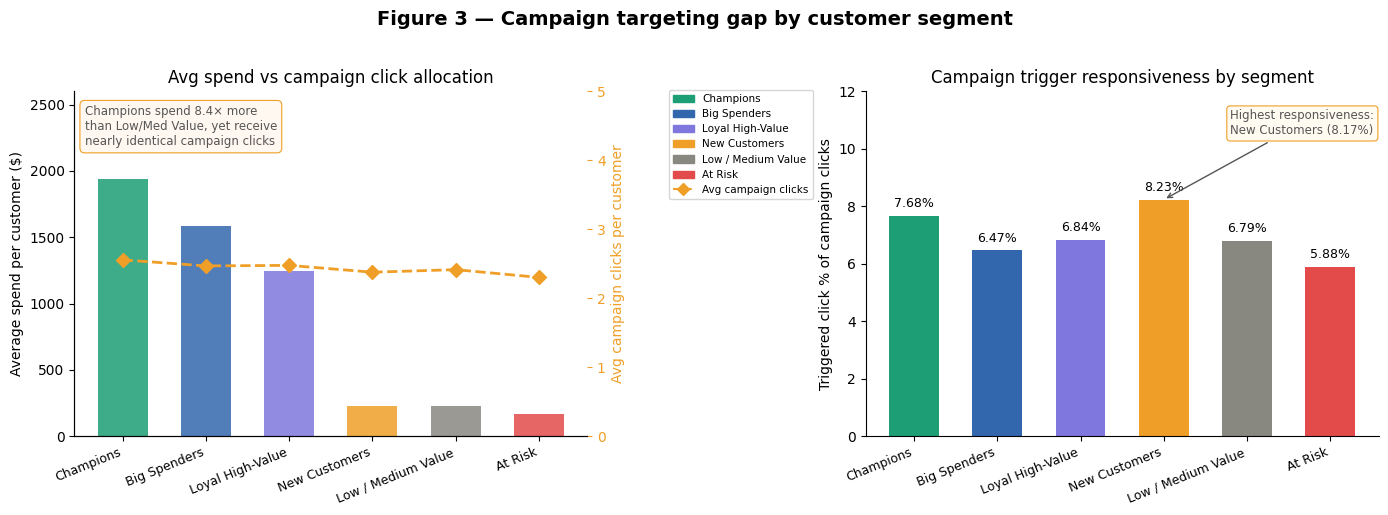

Figure 3 saved


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Figure 3 — Campaign targeting gap by customer segment',
    fontsize=14, fontweight='bold', y=1.02
)

x = np.arange(len(seg_agg))

# ── Left: spend (bars) + campaign clicks (line) ──────────────────────────────
ax_l = axes[0]
ax_r = ax_l.twinx()

ax_l.bar(x, seg_agg['avg_spend'], color=seg_agg['color'], alpha=0.85, width=0.6)
ax_l.set_xticks(x)
ax_l.set_xticklabels(seg_agg['rfm_segment'], rotation=22, ha='right', fontsize=9)
ax_l.set_ylabel('Average spend per customer ($)', fontsize=10)
ax_l.set_title('Avg spend vs campaign click allocation', fontsize=12)
ax_l.set_ylim(0, 2600)
ax_l.spines['top'].set_visible(False)

ax_r.plot(x, seg_agg['avg_camp_clicks'], color='#EF9F27',
          marker='D', lw=2, ms=7, linestyle='--', label='Avg campaign clicks')
ax_r.set_ylabel('Avg campaign clicks per customer', fontsize=10, color='#EF9F27')
ax_r.set_ylim(0, 5)
ax_r.tick_params(axis='y', colors='#EF9F27')
ax_r.spines['top'].set_visible(False)

ax_l.text(0.02, 0.96,
    'Champions spend 8.4× more\nthan Low/Med Value, yet receive\nnearly identical campaign clicks',
    transform=ax_l.transAxes, fontsize=8.5, va='top', color='#555',
    bbox=dict(boxstyle='round,pad=0.4', fc='#fff8f0', ec='#EF9F27', lw=0.8))

legend_handles = [
    mpatches.Patch(color=c, label=s) for s, c in SEG_COLORS.items()
] + [
    plt.Line2D([0], [0], color='#EF9F27', marker='D', ms=6,
               linestyle='--', label='Avg campaign clicks')
]
ax_l.legend(handles=legend_handles, fontsize=7.5,
            loc='upper right', bbox_to_anchor=(1.45, 1.02))

# ── Right: triggered click % ──────────────────────────────────────────────────
bars3 = axes[1].bar(x, seg_agg['triggered_pct'],
                    color=seg_agg['color'], width=0.6)
axes[1].set_xticks(x)
axes[1].set_xticklabels(seg_agg['rfm_segment'], rotation=22, ha='right', fontsize=9)
axes[1].set_ylabel('Triggered click % of campaign clicks', fontsize=10)
axes[1].set_title('Campaign trigger responsiveness by segment', fontsize=12)
axes[1].set_ylim(0, 12)

for bar, val in zip(bars3, seg_agg['triggered_pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.2f}%', ha='center', va='bottom', fontsize=9)

# Annotate New Customers
new_idx = list(seg_agg['rfm_segment']).index('New Customers')
axes[1].annotate(
    'Highest responsiveness:\nNew Customers (8.17%)',
    xy=(new_idx, seg_agg.loc[new_idx, 'triggered_pct']),
    xytext=(new_idx + 0.8, 10.5),
    arrowprops=dict(arrowstyle='->', color='#555', lw=1),
    fontsize=8.5, color='#555',
    bbox=dict(boxstyle='round,pad=0.3', fc='#fffbf0', ec='#EF9F27', lw=0.8)
)

plt.tight_layout()
plt.savefig('figure3_targeting_gap.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 3 saved")

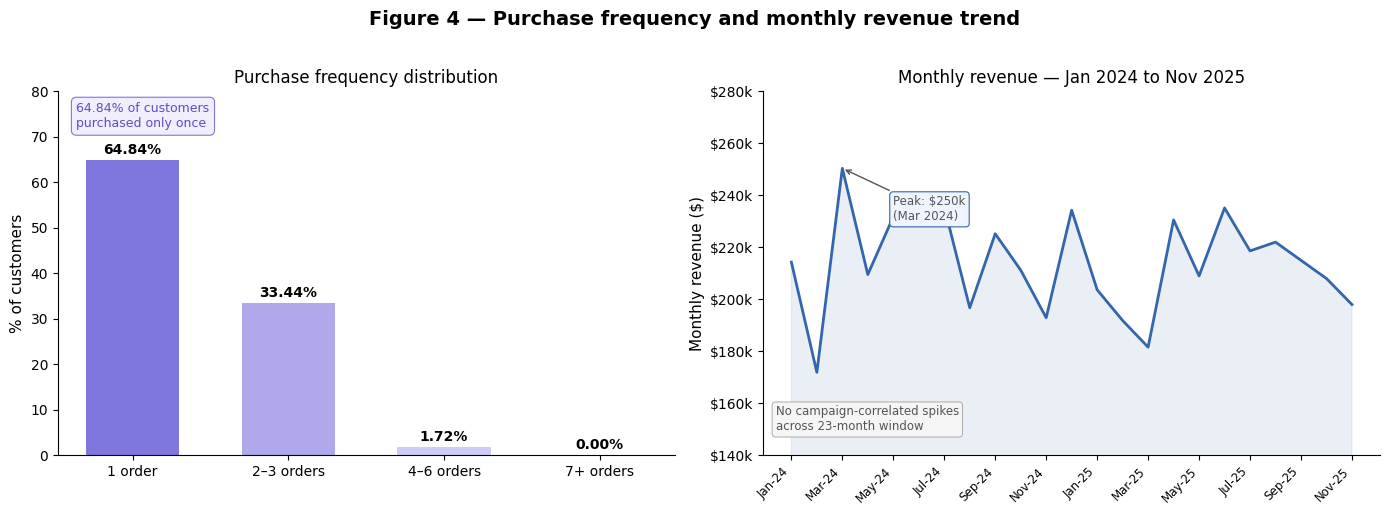

Figure 4 saved


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Figure 4 — Purchase frequency and monthly revenue trend',
    fontsize=14, fontweight='bold', y=1.02
)

# ── Left: frequency distribution ─────────────────────────────────────────────
freq_buckets = pd.cut(
    rfm['frequency'],
    bins=[0, 1, 3, 6, 999],
    labels=['1 order', '2–3 orders', '4–6 orders', '7+ orders']
)
freq_dist = (
    freq_buckets.value_counts(normalize=True)
    .sort_index() * 100
).reset_index()
freq_dist.columns = ['bucket', 'pct']

bucket_colors = ['#7F77DD', '#AFA9EC', '#CECBF6', '#EEEDFE']
bars = axes[0].bar(freq_dist['bucket'], freq_dist['pct'],
                   color=bucket_colors, width=0.6)
axes[0].set_ylabel('% of customers', fontsize=11)
axes[0].set_title('Purchase frequency distribution', fontsize=12)
axes[0].set_ylim(0, 80)

for bar, val in zip(bars, freq_dist['pct']):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.8,
        f'{val:.2f}%',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

axes[0].text(0.03, 0.97,
    '64.84% of customers\npurchased only once',
    transform=axes[0].transAxes, fontsize=9, va='top', color='#5A4FC5',
    bbox=dict(boxstyle='round,pad=0.4', fc='#f0eeff', ec='#7F77DD', lw=0.8))

# ── Right: monthly revenue ────────────────────────────────────────────────────
monthly_rev = {
    'Jan-24': 214302, 'Feb-24': 171917, 'Mar-24': 250383,
    'Apr-24': 209524, 'May-24': 231759, 'Jun-24': 230689,
    'Jul-24': 235560, 'Aug-24': 196747, 'Sep-24': 225213,
    'Oct-24': 211237, 'Nov-24': 192915, 'Dec-24': 234295,
    'Jan-25': 203670, 'Feb-25': 191849, 'Mar-25': 181601,
    'Apr-25': 230536, 'May-25': 208999, 'Jun-25': 235136,
    'Jul-25': 218632, 'Aug-25': 222000, 'Sep-25': 215000,
    'Oct-25': 208000, 'Nov-25': 198000,
}
mo_labels = list(monthly_rev.keys())
mo_vals   = list(monthly_rev.values())

axes[1].plot(range(len(mo_vals)), mo_vals, color='#3266AD', lw=2)
axes[1].fill_between(range(len(mo_vals)), mo_vals, alpha=0.1, color='#3266AD')
axes[1].set_xticks(range(0, len(mo_labels), 2))
axes[1].set_xticklabels(mo_labels[::2], rotation=45, ha='right', fontsize=8.5)
axes[1].set_ylabel('Monthly revenue ($)', fontsize=11)
axes[1].set_title('Monthly revenue — Jan 2024 to Nov 2025', fontsize=12)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f'${v/1000:.0f}k')
)
axes[1].set_ylim(140000, 280000)

peak_idx = mo_vals.index(max(mo_vals))
axes[1].annotate(
    f'Peak: ${max(mo_vals)/1000:.0f}k\n(Mar 2024)',
    xy=(peak_idx, max(mo_vals)),
    xytext=(peak_idx + 2, max(mo_vals) - 20000),
    arrowprops=dict(arrowstyle='->', color='#555', lw=1),
    fontsize=8.5, color='#555',
    bbox=dict(boxstyle='round,pad=0.3', fc='#f0f4ff', ec='#3266AD', lw=0.8)
)
axes[1].text(0.02, 0.06,
    'No campaign-correlated spikes\nacross 23-month window',
    transform=axes[1].transAxes, fontsize=8.5, va='bottom', color='#555',
    bbox=dict(boxstyle='round,pad=0.3', fc='#f5f5f5', ec='#aaa', lw=0.7))

plt.tight_layout()
plt.savefig('figure4_frequency_revenue.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 4 saved")

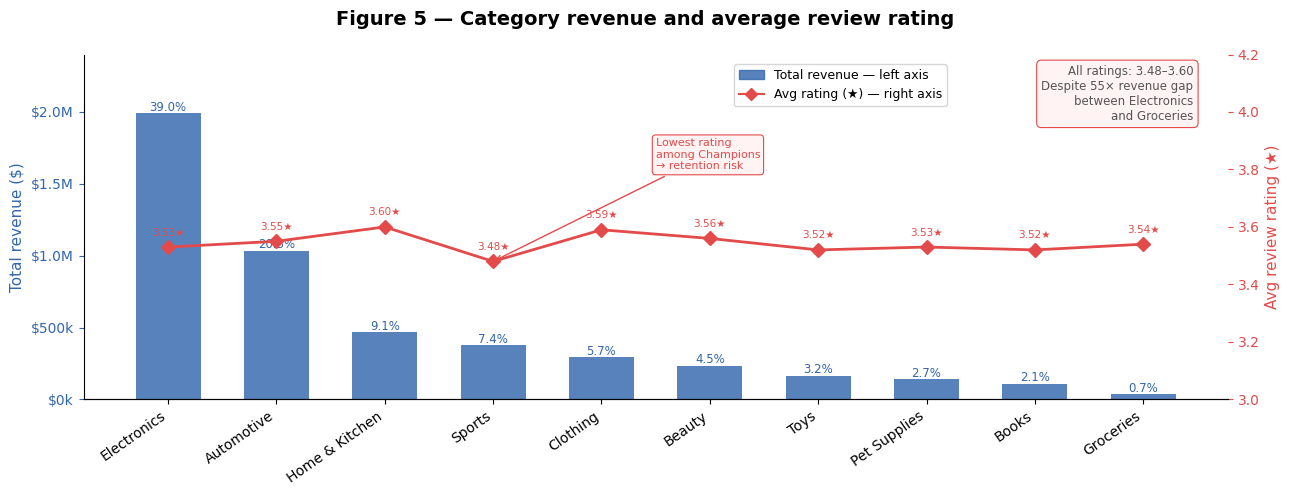

Figure 5 saved


In [15]:
cat_data = pd.DataFrame({
    'category':      ['Electronics','Automotive','Home & Kitchen','Sports',
                       'Clothing','Beauty','Toys','Pet Supplies','Books','Groceries'],
    'total_revenue': [1990350, 1035699, 467168, 376892,
                      291282,  232198,  163687, 140339, 109744, 36217],
    'avg_rating':    [3.53, 3.55, 3.60, 3.48,
                      3.59, 3.56, 3.52, 3.53, 3.52, 3.54],
    'pct_revenue':   [39.0, 20.3, 9.1, 7.4,
                      5.7,  4.5,  3.2, 2.7,  2.1,  0.7],
})

fig, ax1 = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('white')
ax1.set_facecolor('white')
fig.suptitle('Figure 5 — Category revenue and average review rating',
             fontsize=14, fontweight='bold')

x = range(len(cat_data))

bars = ax1.bar(x, cat_data['total_revenue'],
               color='#3266AD', alpha=0.82, width=0.6)
ax1.set_xticks(list(x))
ax1.set_xticklabels(cat_data['category'], rotation=35, ha='right', fontsize=10)
ax1.set_ylabel('Total revenue ($)', fontsize=11, color='#3266AD')
ax1.tick_params(axis='y', colors='#3266AD')
ax1.set_ylim(0, 2400000)
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda v, _: f'${v/1e6:.1f}M' if v >= 1e6 else f'${v/1000:.0f}k'
    )
)
ax1.spines['right'].set_visible(False)

for bar, pct in zip(bars, cat_data['pct_revenue']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 18000,
             f'{pct:.1f}%', ha='center', fontsize=8.5, color='#3266AD')

ax2 = ax1.twinx()
ax2.plot(list(x), cat_data['avg_rating'], color='#E24B4A',
         marker='D', ms=7, lw=2, label='Avg review rating (★)')
ax2.set_ylabel('Avg review rating (★)', fontsize=11, color='#E24B4A')
ax2.set_ylim(3.0, 4.2)
ax2.tick_params(axis='y', colors='#E24B4A')
ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_visible(False)

for xi, row in cat_data.iterrows():
    ax2.text(xi, row['avg_rating'] + 0.04, f'{row["avg_rating"]:.2f}★',
             ha='center', fontsize=7.5, color='#E24B4A')

# Sports annotation — lowest rating among Champions
sports_idx = cat_data[cat_data['category'] == 'Sports'].index[0]
ax2.annotate(
    'Lowest rating\namong Champions\n→ retention risk',
    xy=(sports_idx, cat_data.loc[sports_idx, 'avg_rating']),
    xytext=(sports_idx + 1.5, 3.8),
    arrowprops=dict(arrowstyle='->', color='#E24B4A', lw=1),
    fontsize=8, color='#E24B4A',
    bbox=dict(boxstyle='round,pad=0.3', fc='#fff3f3', ec='#E24B4A', lw=0.8)
)

ax1.text(0.97, 0.97,
    'All ratings: 3.48–3.60\nDespite 55× revenue gap\nbetween Electronics\nand Groceries',
    transform=ax1.transAxes, fontsize=8.5, va='top', ha='right', color='#555',
    bbox=dict(boxstyle='round,pad=0.4', fc='#fff3f3', ec='#E24B4A', lw=0.8))

legend_handles = [
    mpatches.Patch(color='#3266AD', alpha=0.82, label='Total revenue — left axis'),
    plt.Line2D([0], [0], color='#E24B4A', marker='D', ms=6,
               label='Avg rating (★) — right axis'),
]
ax1.legend(handles=legend_handles, fontsize=9,
           loc='upper right', bbox_to_anchor=(0.76, 0.99))

plt.tight_layout()
plt.savefig('figure5_category_revenue.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 5 saved")

In [16]:
from google.colab import files

figures = [
    'figure1_rfm_segments.png',
    'figure2_campaign_funnel.png',
    'figure3_targeting_gap.png',
    'figure4_frequency_revenue.png',
    'figure5_category_revenue.png',
]

for f in figures:
    files.download(f)
    print(f"Downloaded: {f}")

print("\nAll 5 figures downloaded ✓")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: figure1_rfm_segments.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: figure4_frequency_revenue.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: figure5_category_revenue.png

All 5 figures downloaded ✓
